---

# 9. Code Optimization
**[Emil Sekerinski](http://www.cas.mcmaster.ca/~emil/), McMaster University, March 2026**

---

The term _optimization_ is a misnomer, as it refers only to improvements, typically in code size, execution time, memory requirements, and energy consumption. The generated code cannot be optimal for all possible uses.

Optimizing compilers typically use _three-address code_ as an intermediate representation. *Machine-independent optimizations* are carried out on the intermediate representation. *Machine-dependent optimizations* are carried out for the target machine.

Commonly, optimizing compilers consist of a *front-end* that generates the intermediate representation and a *back-end* that generates the executable code.


### Three-Address Code and Basic Blocks

Three-address code resembles RISC code in that all arithmetic and bitwise operators take two operands that are in registers, or one is in a register, and the other is a constant. The differences are:
- There are arbitrarily many registers available. The decision of which registers must be *spilled* to memory is left to the back-end.
- Code is arranged as a graph of labelled *basic blocks*. Jumps can target only labels. An unconditional jump can only occur as the last 

Instructions of three-address code are:

- `$r := c`, loading constant `c` to register `$r`
- `$r := x`, loading the memory at location `x` to register `$r`
- `x := $r`, storing register `$r` to memory at location `x`
- `$r := *$s`, loading the memory at `$s` to register `$r`
- `*$r := $s`, storing register `$s` to memory at `$r`
- `$r := $s ⊕ $t`, binary operation where `⊕` is one of `+`, `-`, `*`, `div`, `mod`, `&`, `|`, `^`, `shl`, `sra`, `srl`, `=`, `≠`, `<`, `≤`, `>`, `≥`
- `goto L`, unconditional jump to instruction with label `L`
- `if $r goto L`, `ifnot $r goto L`, conditional jump to `L`

Formally, if `M` is the memory,

```
x := *y   stands for   x := M[y]
*x := y   stands for   M[x] := y
```

Three-address code is used by [LLVM](http://llvm.org/). Typically, three-address code includes instructions for parameter passing.

<div style="float:right;margin-left:18pt">

```
    $0 := 0
L0: $1 := 0
L1: $2 := 40
    $3 := $0 × $1
    $4 := adr(a)
    $5 := $3 + $4
    $6 := 4
    $7 := $1 × $6
    $8 := $5 + $7
    $9 := 1
    *$8 := $9
    $10 := 1
    $1 := $1 + $10
    $11 := 9
    $12 := $1 ≤ $11
    if $12 goto L1
    $13 := 1
    $0 := $0 + $13
    $14 := 9
    $15 := $0 ≤ $14
    if $15 goto L0
```
</div>

Assume `a: 0 .. 9 → 0 .. 9 → integer` and `size(integer) = 4`:
```
for i := 0 to 9 do
    for j := 0 to 9 do
        a[i, j] := 1
```
As `adr(a[i, j]) = adr(a[i][j]) = adr(a) + i × 10 × size(int) + j × size(int) = adr(a) + i × 40 + j × 4`, a straightforward three-address code for the above program is to the right. Constants `1` and `9` are loaded unnecessarily repeatedly into registers. 

### Common Subexpression Elimination

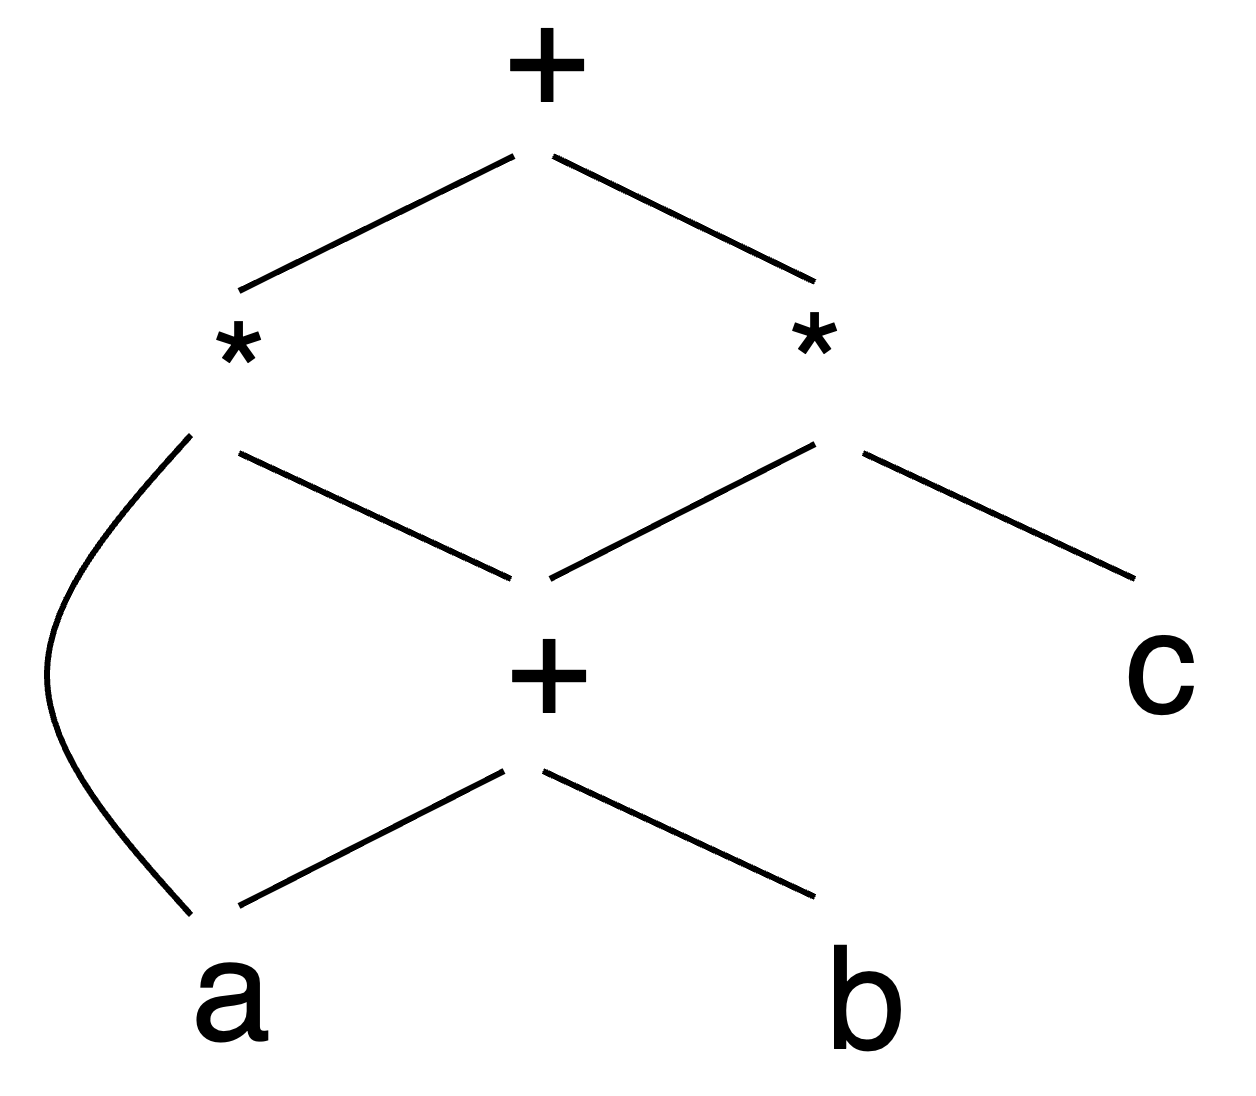</img>
Common subexpression elimination relies on representing the structure of the program not as a tree, but as a directed acyclic graph. The graph is represented by a table that numbers each subexpression. The algorithm for eliminating common subexpressions parses the input from left to right. Each time an expression is recognized, it is looked up in the table, and if it is not present, it is assigned a new number. For example, when in 

    a × (a + b) + (a + b) × c

the first `a` is recognized, it gets the number `$1`; when the second `a` is recognized, nothing changes as `a` has been given a number already; when `b` is recognized, it gets the number `$2`. Now `a + b` is recognized, the operands are replaced with their number and `$1 + $2` is given a new number. This process continues until the end of the expression. 

| expression | number |
|:-----------|:-------|
| `a`        | `$1`   |
| `b`        | `$2`   |
| `$1 + $2`  | `$3`   |
| `$1 × $3`  | `$4`   |
| `c`        | `$5`   |
| `$3 × $5`  | `$6`   |
| `$4 + $6`  | `$7`   |

The subexpression `a + b` could be eliminated in the program source by introducing an auxiliary variable, `t := a + b` and writing `a × t + t × c`. However, without common subexpression elimination, the variables are still repeatedly loaded into registers.

 Common subexpressions may occur in generated code. Given array `: 0 .. 9 → 0 .. 9 → integer`, consider the following assignment:

	a[i, j] := a[i, j] + b[i, j]

The locations of `a[i, j]` and `b[i, j]` need to be determined:

    adr(a[i, j]) = adr(a) + i × 40 + j × 4
    adr(b[i, j]) = adr(b) + i × 40 + j × 4
    
Without common subexpression elimination, the computation of `i × 40 + j × 4` is repeated three times.

Historically, C introduced `+=` to avoid duplicating address calculations:

```C
a[i, j] += b[i, j]
```

That may still evaluate `i × 40 + j × 4` twice. As arrays are pointers in C, and C allows pointer arithmetic, the common subexpression can be factored out explicitly:

```C
    int k = i * 40 + j × 4; *(a + k) += *(b + k)
```

Such optimizations are better left to the compiler.

### Loop Invariant Code Motion

Repeated evaluation of a common subexpression occurs in loops, even though the expression appears only once:

    while i < n - 1 do i := i + 1        =        t := n - 1; while i < t do i := i - 1

Using an auxiliary variable, `t` above, an *invariant expression* can be moved outside the loop. Consider:

```
for i := 0 to 9 do
    for j := 0 to 9 do
        a[i, j] := 1
```

The location of `a[i, j]` is `adr(a) + i × 40 + j × 4`. The expression `adr(a) + i × 40` is invariant in the inner loop and can be moved out of the inner loop.

For this, the dependence of each expression, or registers in three-address form, has to be analyzed: if an expression does not depend on variables modified in a loop, it can be moved outside a loop and its value stored in a register. Care has to be taken that not too many registers are used, as otherwise `splilling` of the registers to memory becomes necessary. 

### Strength Reduction

The idea is to replace arithmetic operatorswithin loops by "weaker" ones. Given `a: 0 .. 9 → integer`, consider:

	for i := m to n do a[i] := x

The location of `a[i]` is `adr(a) + i × 4`. With auxiliary variable (register) `t`, the loop is equivalent to:

    t := adr(a); for i := m to n do (*t := x; t := t + 4)
    
In general, strength reduction follows:

    mⁿ  →  ×  →  +  →  inc

### Dead Code Elimination

Dead code elimination is based on the following identities:

	if true then S else T	=  S
    if false then S else T	=  T
    case c of
        c: S		=  S
        d: T

Dead code arises when debugging (logging, profiling) or when variants of the underlying machine exist:

	if debug then … else …
    case os of
        ios: …
        android: …

This appears when it is easy or efficient to place the variants in different modules and load them selectively. Historically, the C language uses a preprocessor (`#define, #if, #else, #endif`) for this purpose: the source passed to the compiler does not include parts that have been eliminated by the preprocessor. To allow the compiler to report the correct positions of errors, additional preprocessor directives need to be used. With many variants or with overlapping variants, the approach becomes error-prone and is avoided by newer languages.

In three-address code, basic blocks to which there are no jumps are dead code and can be eliminated.

### Algebraic Identities and Constant Folding

*Constant folding* is the evaluation of constant expressions by the compiler, e.g.:

    const A = 5
    const B = 2 × A

    for i := 0 to A - 1 do ...

A language-specific issue is whether compile-time and run-time evaluation should have the same result; they could differ if different precision of integers and floating-point numbers is used. The P0 compiler does constant folding as part of delayed code generation with arbitrary-precision integers, while at run-time, machine integers are used.

Arithmetic and Boolean *algebraic identities* can be used to eliminate operations or to replace some with more time- or energy-efficient ones, like these

	x + 0 = x			x × 0 = 0
    x × 1 = x			x div 1 = x
    b or false = b		b or true = true
    x × 2ⁿ = x shl n		x div 2ⁿ = x asl n

Such expressions can either occur in the source code, typically with symbolic constants, or be generated by the compiler. For example, consider array `a: 0 .. N - 1 → integer`, integers of `4` bytes, and the assignment statement:

    x := a(i)

The address of `a(i)` is:

        adr(a(i))
    = adr(a) + i × size(int)
    = adr(a) + i × 4
    = adr(a) + i shl 2

If `i` is the constant `0`, then `adr(a(0))` simplifies to `adr(a) + 0 shl 2 = adr(a)`; here, constants generated by the compiler are folded.

Dead code elimination uses algebraic identities on program statements.